In [3]:
import os
# Set the environment variable
os.environ['STPSF_PATH'] = os.path.abspath("/npool/nvme/yuchialin/JWST/stpsf_data")
os.environ['WEBBPSF_EXT_PATH'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data"
os.environ['PYSYN_CDBS'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs"
os.environ['CRDS_PATH'] = "/npool/nvme/yuchialin/JWST/crds_cache"
os.environ['CRDS_SERVER_URL'] = "https://jwst-crds.stsci.edu"

# Verify the variable is set
print("STPSF_PATH:", os.environ['STPSF_PATH'])
print("WEBBPSF_EXT_PATH:", os.environ['WEBBPSF_EXT_PATH'])
print("PYSYN_CDBS:", os.environ['PYSYN_CDBS'])
print("CRDS_PATH:", os.environ['CRDS_PATH'])

STPSF_PATH: /npool/nvme/yuchialin/JWST/stpsf_data
WEBBPSF_EXT_PATH: /npool/nvme/yuchialin/JWST/webbpsf_ext_data
PYSYN_CDBS: /npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs
CRDS_PATH: /npool/nvme/yuchialin/JWST/crds_cache


In [4]:
# Imports
from IPython.display import display, HTML

def setup_display(width=95, fontsize=16):
    """
    Sets window width and markdown fontsize for Jupyter notebook. Width is % of window.
    """
    display(HTML("<style>.container { width:"+str(width)+"% !important; }</style>"))
    display(HTML("<style>.rendered_html { font-size: "+str(fontsize)+"px; }</style>"))
    return None

def source(fn):
    import inspect
    print(inspect.getsource(fn))
    return None

import numpy as np
import glob
import winnie
from winnie.plot import animate_quick_implot, quick_implot, mpl, plt
from spaceKLIP import database
import webbpsf
import astropy.units as u

plt.style.use('winnie.winnie_mplstyle') # Comment this out or replace it if you prefer a different plot style

setup_display()

In [5]:
# Prep the SpaceRDI object:
#https://simbad.u-strasbg.fr/simbad/sim-basic?Ident=TW+Hya&submit=SIMBAD+search
#approximately 16.63 milliarcseconds (mas)
#Distance (parsecs) = 1000 / 16.63 ≈ 60.14 parsecs
distance = 60.14 # Distance to your target in parsecs

base_dir = 'data_twhya_winnie/'
input_dir = f'{base_dir}padded/'
data_ext = 'calints'
fitsfiles = np.sort(glob.glob(f'{input_dir}*{data_ext}.fits')) # Populate a file list

# Initialize the spaceKLIP database
Database = database.Database(base_dir)
Database.verbose = False
Database.read_jwst_s012_data(datapaths=fitsfiles)

# Create the SpaceRDI object we'll use to carry out RDI
wdb = winnie.SpaceRDI(Database, output_subdir='WinnieRDI', overwrite=True, verbose=True, pad_data='auto')

In [6]:

import webbpsf_ext

# Create synphot spectrum from BOSZ grid (Bohlin et al 2017, Mészáros et al. 2024, https://archive.stsci.edu/hlsp/bosz)
# In this case, normalized a ~M0V star to 2MASS K'-Band of 7.3 mags
# Stellar properties (Teff=3800K, log_g=4.2) are from Sokal et al (2018, ApJ, 853, 120)
bp_k = webbpsf_ext.bp_2mass('k')
sp = webbpsf_ext.stellar_spectrum('M0V', 7.3, 'vegamag', bp_k, Teff=3800, log_g=4.2, metallicity=0.0)

# You can create arbitrary synphot spectrum from arrays like so:
# sp = webbpsf_ext.synphot_ext.ArraySpectrum(wave=np.array([...]), flux=np.array([...]), wave_unit='angstrom', flux_unit='flam')
# wave_unit can be 'angstrom', 'um', 'nm', etc.
# flux_unit can be 'Jy', 'flam' (erg/s/cm^2/Angstrom), 'photlam' (photons/s/cm^2/Angstrom), etc

# Obtain magnitude values in NIRCam filters
bp_list = ['F200W', 'F356W', 'F444W']
for filt in bp_list:
    bp = webbpsf_ext.nircam_filter(filt, pupil='CIRCLYOT', mask='MASK335R', module='A')
    obs = webbpsf_ext.synphot_ext.Observation(sp, bp, binset=bp.waveset)
    print(f"{filt} Flux Density: {obs.effstim('Jy'):.3f} Jy")

sp = webbpsf_ext.synphot_ext.ArraySpectrum(wave=np.array(sp.wave), flux=np.array(sp.flux))
sp.convert('flam')  # Convert to erg/s/cm^2/Angstrom
#wave = sp.wave
#flux = sp.flux
#wdb.prepare_convolution(sp, fov_pixels=201, osamp=2, grid_kwargs=dict(nr=12, ntheta=4), recalc_psf_grid=True)
wdb.prepare_convolution(sp, fov_pixels=201, osamp=2, grid_kwargs=dict(nr=12, ntheta=4))

# Old Spectrum: Spectrum to assume for the convolution PSFs; we're just using an M0V.
#import stpsf
#spec_synphot = stpsf.specFromSpectralType('M0V', catalog='ck04')
#wdb.prepare_convolution(spec_synphot, fov_pixels=201, osamp=2, grid_kwargs=dict(nr=12, ntheta=4))

F200W Flux Density: 0.857 Jy
F356W Flux Density: 0.359 Jy
F444W Flux Density: 0.237 Jy


In [7]:
# The first time loading each concatenation will take ~5-10 minutes for generating the PSF grid. Reloading later, it should be much quicker.
wdb.load_concat(0)

JWST_NIRCAM_NRCA2_F200W_MASKRND_MASK335R_SUB320A335R
Science data:   2 exposures of shape (650,650)
Reference data: 241 exposures of shape (650,650)

RDI Settings:
Mode: RDI (Winnie)
Extension for output files: 'rdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)
Setting up sim to match data_twhya_winnie/padded/jw01179005001_03107_00001_nrca2_calints.fits

MAST OPD query around UTC: 2024-02-14T10:22:56.420
                        MJD: 60354.432597453706

OPD immediately preceding the given datetime:
	URI:	 mast:JWST/product/O2024021301-NRCA3_FP1-1.fits
	Date (MJD):	 60353.2554
	Delta time:	 -1.1772 days

OPD immediately following the given datetime:
	URI:	 mast:JWST/product/O2024021601-NRCA3_FP1-1.fits
	Date (MJD):	 60355.7958
	Delta time:	 1.3632 days
User requested choosing OPD time closest in time to 2024-02-14T10:22:56.420, which is O2024021301-NRCA3_FP1-1.fits, delta time -1.177 days
Importing and format-converting OPD from /npool/nvme/yuchialin/JWST/stpsf_data/MAST_JWST_WSS_

In [8]:
# Run a HPFRDI reduction with default settings.
wdb.hpfrdi_presets()
rdi_reduc = wdb.run_rdi()

JWST_NIRCAM_NRCA2_F200W_MASKRND_MASK335R_SUB320A335R
Science data:   2 exposures of shape (650,650)
Reference data: 241 exposures of shape (650,650)

RDI Settings:
Mode: HPFRDI (Winnie)
'opt_smoothing_fn': <function high_pass_filter_sequence at 0x797c7f1ee520>
'opt_smoothing_kwargs': {'filtersize': 1.0994602853484432}
Extension for output files: 'hpfrdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)


In [9]:
# Disk modeling functions and imports
from winnie.utils import px_size_to_ang_size, ang_size_to_proj_sep, median_filter_sequence
import vip_hci as vip
from vip_hci.fm import ScatteredLightDisk, Phase_function
from astropy import convolution
from IPython.display import clear_output

def grater_2hg_disk_model(r0, h0, ain, aout, pa, incl, g1, g2, wg1,
                          e=0., omega=0., gamma=2., beta=1., xdo=0, ydo=0,
                          cent=np.array([160.,160.]), distance=10., nx=320, ny=320,
                          pxscale=0.063*u.arcsec/u.pixel, accuracy=None, rmax_accuracy=None,
                          halfNbSlices=25, polar=False, flux_max=None):
    """
    A simple ring-like disk morphology based on Augereau et al. (1999) and assuming a linear combo of two H-G SPFs as the scattering phase function.

    r0: fiducial radius in au
    h0: technically h0/r0 — the ratio of scale height to fiducial radius at the fiducial radius
    ain: radial density power law exponent interior to r0
    aout: radial density power law exponent exterior to r0
    pa: disk position angle in degrees
    incl: disk inclination in degrees
    g1: 1st Henyey-Greenstein asymmetry parameter
    g2: 2nd Henyey-Greenstein asymmetry parameter
    wg1: Weight for the SPF term with asymmetry parameter g1 (value in range 0-1); wg2 is 1-wg1
    e: eccentricity
    omega: argument of pericenter in degrees
    gamma: vertical density exponent (gamma = 2 for gaussian)
    beta: disk radial flaring exponent (beta = 1 for linear)

    cent: the pixel position for the center of the disk (generally the location of the star in the data)
    distance: distance to the target in parsecs
    nx: number of x-axis pixels for the image
    ny: number of y-axis pixels for the image
    pxscale: the pixel scale for the data; either a float (must be arcsec/pixel) or astropy units (any units that can be cast to arcsec/pixel)
    accuracy: the numerical accuracy for the model; pixels with density below this value will be set to zero
    rmax_accuracy: if accuracy is None, the model's accuracy is set such that non-zero values are achieved to this separation (in au)
    halfNbSlices: the number of planar slices to compute above and below the disk midplane
    polar: if True, a simple bell-shaped polarization curve is used to generate a polarized intensity image
    flux_max: if not None, normalize the model image so that this is the maximum value.
    """

    def dont_actually_check_inclination(*args, **kwargs):
        """
        VIP's ScatteredLightDisk will normally decrease disk inclination if too high.
        This will cause issues for optimization, so we'd rather live with the artifacts / etc.
        Instead, we just tell VIP that the incl is good whenever it checks.
        We accept *args and **kwargs so it safely replaces the class method.
        """
        return None

    if accuracy is None:
        if rmax_accuracy is None:
            im_corner_dists = np.hypot(*(np.array([[0, 0], [0, ny-1], [nx-1, 0], [nx-1, ny-1]])-cent).T)
            rmax_accuracy = ang_size_to_proj_sep(px_size_to_ang_size(np.max(im_corner_dists), pxscale), distance).value
        accuracy = (rmax_accuracy/r0)**(aout)

    spf = {'name':'DoubleHG', 'g': [g1, g2], 'weight': wg1, 'polar': polar}
    dens = {'name': '2PowerLaws', 'ain': ain, 'aout': aout, 'a': r0, 'ksi0':h0*r0,
            'e': e, 'gamma': gamma, 'beta': beta, 'accuracy': accuracy}

    vip_disk = ScatteredLightDisk(nx=nx, ny=ny, distance=distance,
                                  itilt=incl, pxInArcsec=(pxscale << u.arcsec/u.pixel).value,
                                  pa=pa-180., omega=omega, xdo=xdo, ydo=ydo,
                                  density_dico=dens, spf_dico=spf, flux_max=flux_max,
                                  xs=cent[0], ys=cent[1])

    vip_disk.dust_density.accuracy = accuracy
    vip_disk.dust_density.dust_distribution_calc.rmax = vip_disk.dust_density.dust_distribution_calc.a*accuracy**(1/vip_disk.dust_density.dust_distribution_calc.aout)
    
    # Override check_inclination bounding to avoid breaking optimization
    vip_disk.check_inclination = dont_actually_check_inclination.__get__(vip_disk, ScatteredLightDisk)
    
    disk = vip_disk.compute_scattered_light(halfNbSlices=halfNbSlices)

    # For disks with material coincident with the stellar position along the line of sight, VIP returns an image with a plus-sign shaped region of zeros at the star's position
    # The below is a quick work-around to correct this. Very likely makes zero difference following PSF-convolution
    if cent[0]%1 == 0:
        jvals = (np.array([-1,0,1])+cent[0]).astype(int)
    else:
        jvals = np.array([np.floor(cent[0]), np.ceil(cent[0])]).astype(int)
        
    if cent[1]%1 == 0:
        ivals = (np.array([-1,0,1])+cent[1]).astype(int)
    else:
        ivals = np.array([np.floor(cent[1]), np.ceil(cent[1])]).astype(int)
        
    for j in jvals:
        disk[int(cent[1]),j] = np.nan
    for i in ivals:
        disk[i,int(cent[0])] = np.nan
        
    disk = convolution.interpolate_replace_nans(disk, np.ones((3,3)))
    return disk

# Single Ring Model Optimization

Fixed Parameters
- ring locations (r0): 52 AU
- scale height (h0): 0.035
- dust density distribution (ain, aout): 5, -5
- scattering phase function parameters (g1, g2, wg1): 0.85, -0.2, 0.75
- disk geometry (incl, pa): 0, 0

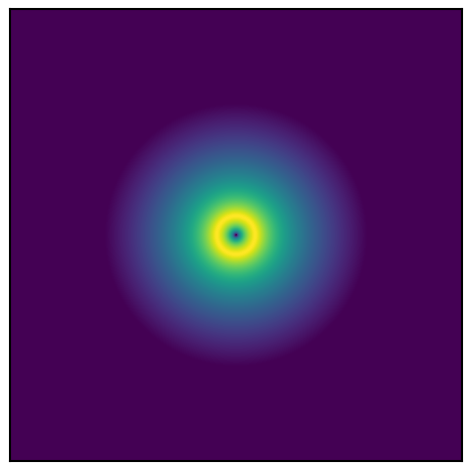

In [10]:
# Disk parameters (see grater_2hg_disk_model docstring)
# These are just some quick guesses to get something resembling what we actually see
r0, h0, ain, aout, pa, incl =  52, 0.035, 5, -5, 0, 0
g1, g2, wg1 = 0.85, -0.2, 0.75
flux_max = 135.127

raw_model = grater_2hg_disk_model(r0, h0, ain, aout, pa, incl, g1, g2, wg1,
                                  cent=wdb.c_star, distance=distance,
                                  nx=wdb.nx, ny=wdb.ny, pxscale=wdb.pxscale,
                                  flux_max=flux_max)

quick_implot(raw_model, norm=mpl.colors.LogNorm, norm_kwargs=dict(clip=True), clim='0.00001*99.99%, 99.99%')


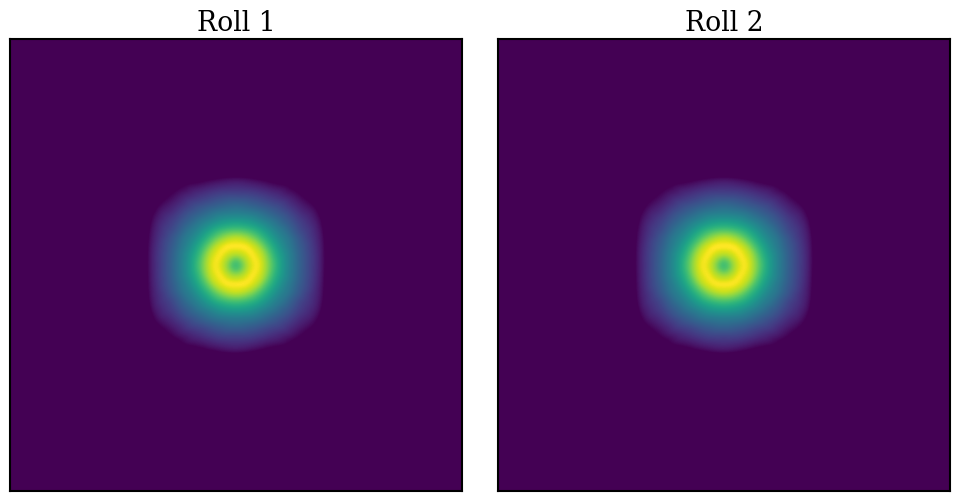

In [11]:
# Resample our raw model (if needed), rotate it to the position angles of the observations, multiply it by the coronagraph transmission map for each roll,
# and then convolve our raw model with the previously generated PSF grid:

model_cube = wdb.convolver.convolve_model(raw_model, wdb.pxscale, wdb.c_star)

fig,axes = quick_implot(model_cube, norm=mpl.colors.LogNorm, norm_kwargs=dict(clip=True), clim='0.001*99.99%, 99.99%', show=False)

for i, ax in enumerate(axes):
    ax.set_title(f'Roll {i+1}')
    
plt.show()

In [12]:
# Set the resulting model_cube as our circumstellar scene (CSS) model in the Winnie SpaceRDI object
# Then, run High Pass Filtered RDI (HPFRDI) with the forward model option enabled to generate a model RDI image for this disk model.
wdb.set_circumstellar_model(model_cube=model_cube)
wdb.hpfrdi_presets()
hpfrdi_singlering = wdb.run_rdi(forward_model=True)

JWST_NIRCAM_NRCA2_F200W_MASKRND_MASK335R_SUB320A335R
Science data:   2 exposures of shape (650,650)
Reference data: 241 exposures of shape (650,650)

RDI Settings:
Mode: HPFRDI (Winnie)
'opt_smoothing_fn': <function high_pass_filter_sequence at 0x7cafd4ab65c0>
'opt_smoothing_kwargs': {'filtersize': 1.0994602853484432}
Extension for output files: 'hpfrdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)


Recommended flux max for the model: 135.127


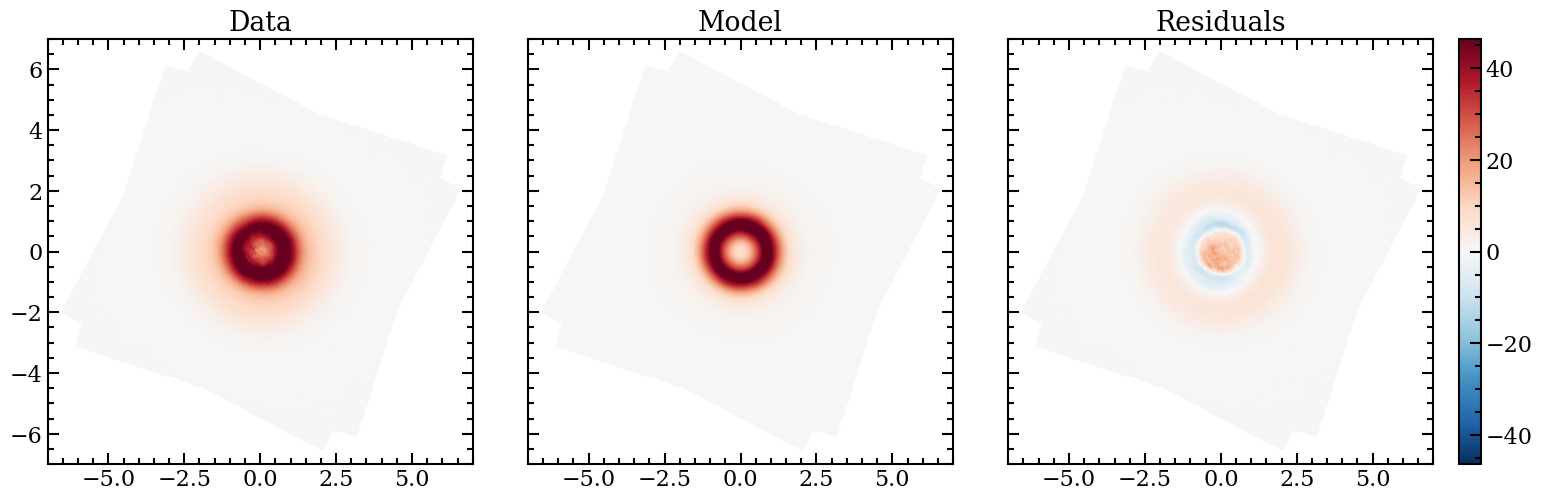

In [13]:
# Plot data, model, and residuals
recom_flux_max = np.nansum(rdi_reduc.im*hpfrdi_singlering.im) / np.nansum(hpfrdi_singlering.im**2)*flux_max
print(f"Recommended flux max for the model: {recom_flux_max:.3f}")
fig,axes,cbar = quick_implot([rdi_reduc.im, hpfrdi_singlering.im, rdi_reduc.im-hpfrdi_singlering.im], cmap='RdBu_r', clim_perc=99, show=False, cbar=True, cbar_kwargs=dict(pad=0.015), panelsize=(6,5), extent=rdi_reduc.extent, lims=[-7,7], show_ticks=True)

labels = ['Data', 'Model', 'Residuals']
for i,ax in enumerate(axes):
    ax.set_title(labels[i])

# Three Rings Optimization

Fixed Parameters
- scale height (h0): 0.035
- dust density distribution (ain, aout): 5, -5
- scattering phase function parameters (g1, g2, wg1): 0.85, -0.2, 0.75

### Optimize three-ring disk parameters with ring-2 residual scaling (PA & incl fixed to 0)

In [14]:
# Disk parameters (see grater_2hg_disk_model docstring)
# These are just some quick guesses to get something resembling what we actually see
r0, h0, ain, aout, pa, incl =  52, 0.035, 5, -5, 0, 0
g1, g2, wg1 = 0.85, -0.2, 0.75

### Optimize three-ring disk parameters with separate PA and inclination for each ring
seems the benefit of separate PA and inclination for each ring is not significant, so we can just fix them to 0 for simplicity.

[eval 8] new best 0.7646 | r01=30.77, r02=53.43, r03=118.09, pa1=110.20, pa2=48.68, pa3=104.56, incl1=-6.15, incl2=9.47, incl3=4.23
[eval 9] new best 0.6779 | r01=29.79, r02=53.98, r03=117.02, pa1=105.53, pa2=50.74, pa3=63.18, incl1=-3.32, incl2=-9.87, incl3=-1.05
[eval 12] new best 0.6773 | r01=29.13, r02=54.07, r03=117.72, pa1=121.04, pa2=17.54, pa3=17.35, incl1=7.16, incl2=1.79, incl3=-5.49
[eval 20] cost 0.8697, best 0.6773
[eval 40] cost 1.13, best 0.6773
[eval 60] cost 1.019, best 0.6773
[eval 80] cost 0.7635, best 0.6773
[eval 94] new best 0.6757 | r01=29.36, r02=53.74, r03=117.39, pa1=95.21, pa2=55.46, pa3=59.14, incl1=-1.12, incl2=2.63, incl3=-3.12
[eval 97] new best 0.6739 | r01=29.28, r02=53.95, r03=117.56, pa1=0.31, pa2=52.27, pa3=37.83, incl1=-5.28, incl2=4.58, incl3=-3.68
[eval 100] cost 1.125, best 0.6739
[eval 102] new best 0.6738 | r01=29.03, r02=53.58, r03=118.18, pa1=155.03, pa2=77.54, pa3=5.86, incl1=-0.24, incl2=-4.67, incl3=-4.40
[eval 120] cost 0.6941, best 0.673

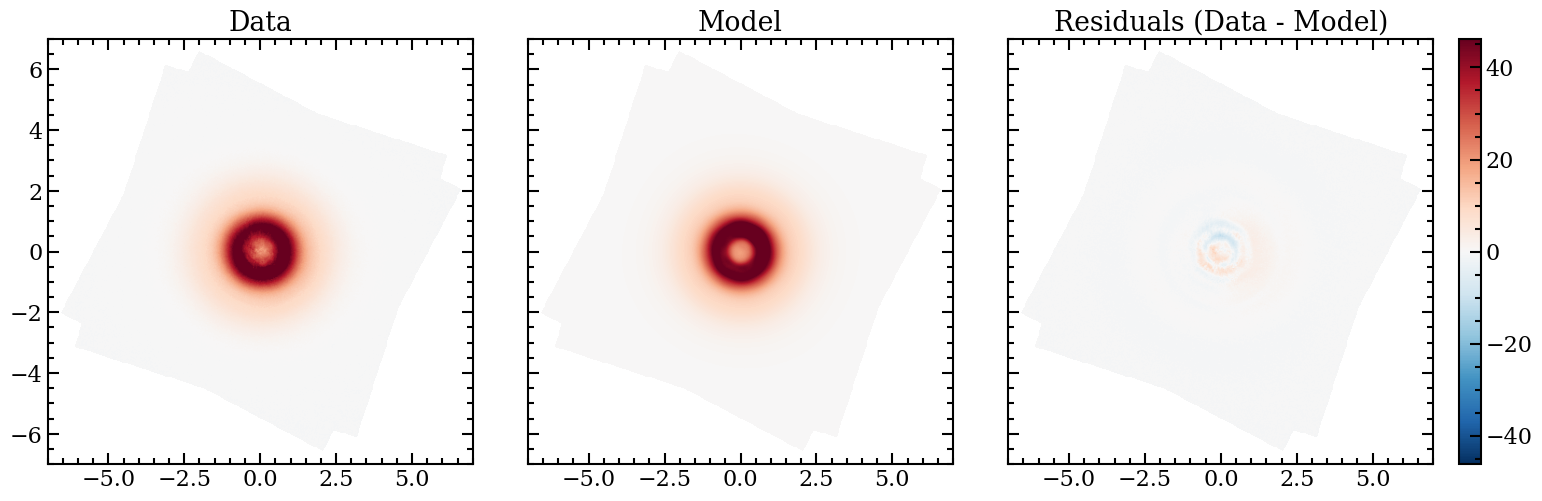

In [25]:
# Optimize three-ring disk parameters with separate PA and inclination for each ring
from scipy.optimize import differential_evolution
from multiprocessing.pool import ThreadPool
import numpy as np

# User-set ring ranges in AU (low, high) for three rings
ring_ranges_au = [
    (29, 32),   # Ring 1 range
    (53, 56),   # Ring 2 range
    (115, 120), # Ring 3 range
]

# Fixed values from previous optimization
flux1_fixed = 272.887
flux2_fixed = 83.502
flux3_fixed = 9.124

# Other constants (assuming spatial parameters are still defined as h0, ain etc. in the environment)
h0_fixed = h0
ain_fixed = ain
aout_fixed = aout
g1_fixed = g1
g2_fixed = g2
wg1_fixed = wg1

n_workers = 8  # threads; shared memory keeps logging consistent

# Bounds: pa1, pa2, pa3, incl1, incl2, incl3
# PA bounds typically [0, 360], inclination bounds [0, 89]
bounds = [
    (ring_ranges_au[0][0], ring_ranges_au[0][1]),  # r01
    (ring_ranges_au[1][0], ring_ranges_au[1][1]),  # r02
    (ring_ranges_au[2][0], ring_ranges_au[2][1]),  # r03
    (0.0, 180.0),  # pa1
    (0.0, 180.0),  # pa2
    (0.0, 180.0),  # pa3
    (-10.0, 10.0),   # incl1
    (-10.0, 10.0),   # incl2
    (-10.0, 10.0),   # incl3
]

# Precompute radius map in AU for the evaluation mask
ny, nx = wdb.ny, wdb.nx
j, i = np.meshgrid(np.arange(nx), np.arange(ny))
cent = wdb.c_star
r_pix = np.hypot(i - cent[1], j - cent[0])
r_au = ang_size_to_proj_sep(px_size_to_ang_size(r_pix, wdb.pxscale), distance).value

# Eval mask: evaluates over a general domain spanning all three rings
eval_mask = (r_au >= 10) & (r_au <= 200)

progress_state = {"eval": 0, "best": np.inf}

def build_ring_raw(r0_val, pa_val, incl_val, flux_val):
    return grater_2hg_disk_model(
        r0_val,
        h0_fixed,
        ain_fixed,
        aout_fixed,
        pa_val,
        incl_val,
        g1_fixed,
        g2_fixed,
        wg1_fixed,
        cent=wdb.c_star,
        distance=distance,
        nx=wdb.nx,
        ny=wdb.ny,
        pxscale=wdb.pxscale,
        flux_max=flux_val, # Now fully fixed
    )

def forward_model_from_raw(raw):
    model_cube = wdb.convolver.convolve_model(raw, wdb.pxscale, wdb.c_star)
    wdb.set_circumstellar_model(model_cube=model_cube)
    return wdb.run_rdi(forward_model=True).im

def objective(theta):
    (
        r01,
        r02,
        r03,
        pa1_val,
        pa2_val,
        pa3_val,
        incl1_val,
        incl2_val,
        incl3_val,
    ) = theta
    progress_state["eval"] += 1

    try:
        # Build each ring with its independent PA and inclination, and predefined fixed fluxes and radii
        raw1 = build_ring_raw(r01, pa1_val, incl1_val, flux1_fixed)
        raw2 = build_ring_raw(r02, pa2_val, incl2_val, flux2_fixed)
        raw3 = build_ring_raw(r03, pa3_val, incl3_val, flux3_fixed)

        # Forward model all three
        fm = forward_model_from_raw(raw1+raw2+raw3)
        cost = np.nanmean(np.abs((rdi_reduc.im - fm)[eval_mask]))
    except Exception as exc:  # Return a large penalty on failures
        print(f"[eval {progress_state['eval']}] evaluation failed: {exc}")
        return np.inf

    if cost < progress_state["best"]:
        progress_state["best"] = cost
        print(
            f"[eval {progress_state['eval']}] new best {cost:.4g} | "
            f"r01={r01:.2f}, r02={r02:.2f}, r03={r03:.2f}, "
            f"pa1={pa1_val:.2f}, pa2={pa2_val:.2f}, pa3={pa3_val:.2f}, "
            f"incl1={incl1_val:.2f}, incl2={incl2_val:.2f}, incl3={incl3_val:.2f}"
        )
    elif progress_state["eval"] % 20 == 0:
        print(
            f"[eval {progress_state['eval']}] cost {cost:.4g}, best {progress_state['best']:.4g}"
        )

    return cost

def progress_callback(xk, convergence):
    print(
        f"[iter heartbeat] evals={progress_state['eval']}, current best={progress_state['best']:.4g}, convergence={convergence:.3g}"
    )
    return False

pool = ThreadPool(n_workers)
try:
    result = differential_evolution(
        objective,
        bounds,
        maxiter=40,
        popsize=n_workers,
        seed=39,
        polish=False,
        workers=pool.map,  # threads share state with main process
        updating="deferred",
        callback=progress_callback,
    )
finally:
    pool.close()
    pool.join()

(   
    best_r01,
    best_r02,
    best_r03,
    best_pa1,
    best_pa2,
    best_pa3,
    best_incl1,
    best_incl2,
    best_incl3,
) = result.x

print("Optimization complete")
print(
    f"r01={best_r01:.2f}, r02={best_r02:.2f}, r03={best_r03:.2f}, "
    f"pa1={best_pa1:.2f}, pa2={best_pa2:.2f}, pa3={best_pa3:.2f}, "
    f"incl1={best_incl1:.2f}, incl2={best_incl2:.2f}, incl3={best_incl3:.2f}"
)

# Build best-fit ring models with optimized pa and incl
best_raw1 = build_ring_raw(best_r01, best_pa1, best_incl1, flux1_fixed)
best_raw2 = build_ring_raw(best_r02, best_pa2, best_incl2, flux2_fixed)
best_raw3 = build_ring_raw(best_r03, best_pa3, best_incl3, flux3_fixed)

best_fm = forward_model_from_raw(best_raw1+best_raw2+best_raw3)

fig, axes, cbar = quick_implot(
    [rdi_reduc.im, best_fm, rdi_reduc.im - best_fm],
    cmap="RdBu_r",
    clim_perc=99,
    show=False,
    cbar=True,
    cbar_kwargs=dict(pad=0.015),
    panelsize=(6, 5),
    extent=rdi_reduc.extent,
    lims=[-7, 7],
    show_ticks=True,
)
for ax, title in zip(axes, ["Data", "Model", "Residuals (Data - Model)"]):
    ax.set_title(title)
plt.show()